# Used Car Price Prediction Portfolio Notebook

This notebook rebuilds the car price project from scratch as a **clean, deployment-aware regression workflow**.

**Project goal**
- Predict `selling_price` for a used-car listing from the raw listing fields.

**Why this version is portfolio-ready**
- leakage-safe data splitting
- reusable raw-to-features transformer
- targeted EDA instead of plot spam
- strong feature engineering from messy vehicle specs
- comparison of multiple model families
- tuning, diagnostics, and final held-out test evaluation
- saved model artifact ready for later Streamlit integration


## Pipeline Blueprint

1. Load the local CSV and validate the raw schema.
2. Audit data quality: missingness, duplicates, skew, and category structure.
3. Engineer domain-aware features from `name`, `mileage`, `engine`, `max_power`, and `torque`.
4. Use a duplicate-safe, stratified `train / validation / test` split.
5. Compare at least four regressors on the same pipeline.
6. Tune the strongest challengers.
7. Choose a champion model on validation data, then evaluate once on the untouched test set.
8. Save the fitted pipeline and inference contract for future Streamlit deployment.


In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    # Fallback for scikit-learn < 1.4
    def root_mean_squared_error(y_true, y_pred, **kwargs):
        return np.sqrt(mean_squared_error(y_true, y_pred, **kwargs))
from sklearn.model_selection import KFold, ParameterGrid, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
DATA_PATH = Path("Car details v3.csv")
PROJECT_DIR = Path.cwd()
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

for folder in [MODELS_DIR, REPORTS_DIR, ARTIFACTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR.resolve()}")
print(f"Dataset exists: {DATA_PATH.exists()}")


Project directory: /Users/dannyyy/Downloads/BCU projects/3Y: Machine Learning
Dataset exists: True


## 1. Data Contract And Raw Ingestion

The future Streamlit app should send the **same raw columns** that this training pipeline expects.
The saved model artifact will therefore accept raw listing-style inputs rather than pre-engineered features.


In [2]:
RAW_FEATURE_COLUMNS = [
    "name",
    "year",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "torque",
    "seats",
]
TARGET_COLUMN = "selling_price"
REQUIRED_COLUMNS = RAW_FEATURE_COLUMNS + [TARGET_COLUMN]

def validate_training_frame(df: pd.DataFrame) -> dict:
    missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    target_numeric = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    summary = {
        "rows": int(len(df)),
        "columns": int(df.shape[1]),
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_target_rows": int(target_numeric.isna().sum()),
        "non_positive_target_rows": int((target_numeric <= 0).fillna(False).sum()),
    }
    return summary

raw_df = pd.read_csv(DATA_PATH)
quality_summary = validate_training_frame(raw_df)

display(pd.Series(quality_summary, name="quality_summary").to_frame())
display(raw_df.head())


,quality_summary
rows,8128
columns,13
duplicate_rows,1202
missing_target_rows,0
non_positive_target_rows,0


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
audit_df = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_pct": raw_df.isna().mean().mul(100).round(2),
        "n_unique": raw_df.nunique(dropna=False),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

price_quantiles = (
    pd.to_numeric(raw_df[TARGET_COLUMN], errors="coerce")
    .quantile([0.50, 0.90, 0.95, 0.99])
    .rename("selling_price")
)

display(audit_df)
display(price_quantiles.to_frame())
print(f"Exact duplicate rows: {raw_df.duplicated().sum():,}")


,dtype,missing_pct,n_unique
torque,object,2.73,442
mileage,object,2.72,394
engine,object,2.72,122
seats,float64,2.72,10
max_power,object,2.65,323
name,object,0.00,2058
km_driven,int64,0.00,921
selling_price,int64,0.00,677
year,int64,0.00,29
owner,object,0.00,5


,selling_price
0.50,450000.0
0.90,1025000.0
0.95,1950000.0
0.99,5200000.0


Exact duplicate rows: 1,202


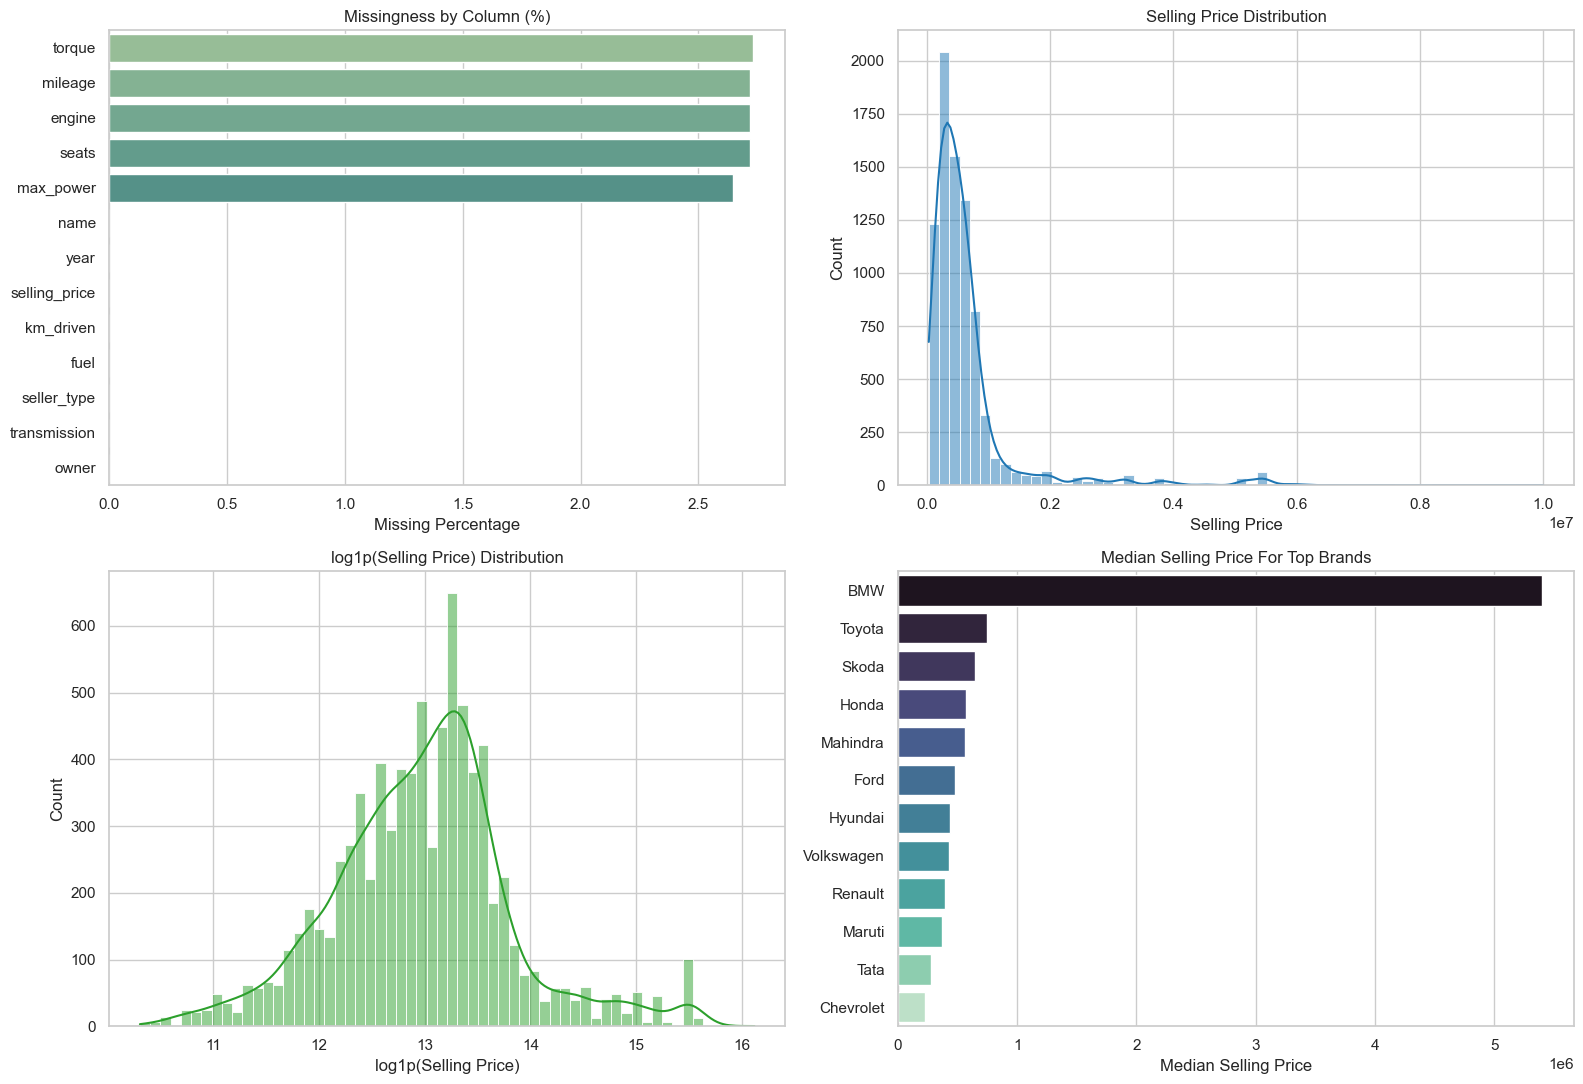

In [4]:
eda_df = raw_df.copy()
eda_df[TARGET_COLUMN] = pd.to_numeric(eda_df[TARGET_COLUMN], errors="coerce")
eda_df["brand"] = eda_df["name"].fillna("Unknown").astype(str).str.split().str[0]

top_brand_counts = eda_df["brand"].value_counts().head(12)
median_price_by_brand = (
    eda_df.loc[eda_df["brand"].isin(top_brand_counts.index)]
    .groupby("brand")[TARGET_COLUMN]
    .median()
    .sort_values(ascending=False)
)

missing_pct = raw_df.isna().mean().sort_values(ascending=False).mul(100)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=axes[0, 0], palette="crest")
axes[0, 0].set_title("Missingness by Column (%)")
axes[0, 0].set_xlabel("Missing Percentage")
axes[0, 0].set_ylabel("")

sns.histplot(eda_df[TARGET_COLUMN], bins=60, kde=True, ax=axes[0, 1], color="#1f77b4")
axes[0, 1].set_title("Selling Price Distribution")
axes[0, 1].set_xlabel("Selling Price")

sns.histplot(np.log1p(eda_df[TARGET_COLUMN]), bins=60, kde=True, ax=axes[1, 0], color="#2ca02c")
axes[1, 0].set_title("log1p(Selling Price) Distribution")
axes[1, 0].set_xlabel("log1p(Selling Price)")

sns.barplot(
    x=median_price_by_brand.values,
    y=median_price_by_brand.index,
    ax=axes[1, 1],
    palette="mako",
)
axes[1, 1].set_title("Median Selling Price For Top Brands")
axes[1, 1].set_xlabel("Median Selling Price")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()


In [5]:
model_df = raw_df.drop_duplicates().copy()
model_df[TARGET_COLUMN] = pd.to_numeric(model_df[TARGET_COLUMN], errors="coerce")
model_df = model_df.loc[model_df[TARGET_COLUMN].notna() & (model_df[TARGET_COLUMN] > 0)].reset_index(drop=True)

print(f"Rows before deduplication: {len(raw_df):,}")
print(f"Rows after deduplication and target cleaning: {len(model_df):,}")
print(f"Rows removed: {len(raw_df) - len(model_df):,}")


Rows before deduplication: 8,128
Rows after deduplication and target cleaning: 6,926
Rows removed: 1,202


## 2. Reusable Feature Engineering

The core idea is to learn from the **raw listing text and raw vehicle spec fields**, then convert them into a stable feature frame.

Key upgrades over the original notebooks:
- parse `mileage` while preserving the unit (`kmpl` vs `km/kg`)
- parse `torque` instead of throwing it away
- engineer age and usage-intensity signals
- keep the raw title as a text feature for trim-level cues like `VDI`, `CRDi`, `LXI`, and `Automatic`
- group rare brands for stability at inference time


In [6]:
def extract_first_float(series: pd.Series) -> pd.Series:
    cleaned = series.fillna("").astype(str).str.replace(",", "", regex=False)
    extracted = cleaned.str.extract(r"([-+]?\d*\.?\d+)")[0]
    return pd.to_numeric(extracted, errors="coerce")

def parse_mileage_columns(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    cleaned = series.fillna("").astype(str).str.lower().str.strip()
    mileage_value = extract_first_float(cleaned)
    mileage_unit = np.select(
        [
            cleaned.str.contains("km/kg", regex=False),
            cleaned.str.contains("kmpl", regex=False),
        ],
        [
            "km_per_kg",
            "km_per_liter",
        ],
        default="unknown",
    )
    return mileage_value, pd.Series(mileage_unit, index=series.index)

def parse_torque_columns(series: pd.Series) -> tuple[pd.Series, pd.Series, pd.Series]:
    cleaned = (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    torque_value = extract_first_float(cleaned)
    is_kgm = cleaned.str.contains("kgm", regex=False)
    torque_nm = torque_value.where(~is_kgm, torque_value * 9.80665)

    rpm_match = cleaned.str.extract(r"(?:@|at)\s*([0-9]+)(?:\s*-\s*([0-9]+))?")
    torque_rpm_low = pd.to_numeric(rpm_match[0], errors="coerce")
    torque_rpm_high = pd.to_numeric(rpm_match[1], errors="coerce").fillna(torque_rpm_low)

    return torque_nm, torque_rpm_low, torque_rpm_high

def normalise_listing_text(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"[^a-z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

class VehicleFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, reference_year: int | str = "auto", min_brand_count: int = 25):
        self.reference_year = reference_year
        self.min_brand_count = min_brand_count

    def fit(self, X, y=None):
        X = self._coerce_frame(X)
        years = pd.to_numeric(X["year"], errors="coerce")
        if self.reference_year == "auto":
            self.reference_year_ = int(years.max()) + 1
        else:
            self.reference_year_ = int(self.reference_year)

        brands = (
            X["name"]
            .fillna("Unknown")
            .astype(str)
            .str.split()
            .str[0]
            .fillna("Unknown")
        )
        brand_counts = brands.value_counts()
        self.kept_brands_ = set(brand_counts[brand_counts >= self.min_brand_count].index)
        return self

    def transform(self, X):
        X = self._coerce_frame(X)
        missing_columns = [col for col in RAW_FEATURE_COLUMNS if col not in X.columns]
        if missing_columns:
            raise ValueError(f"Missing raw inference columns: {missing_columns}")

        listing_name = X["name"].fillna("Unknown").astype(str)
        brand_raw = listing_name.str.split().str[0].fillna("Unknown")
        brand = brand_raw.where(brand_raw.isin(self.kept_brands_), "Other")

        year = pd.to_numeric(X["year"], errors="coerce")
        km_driven = pd.to_numeric(X["km_driven"], errors="coerce")
        seats = pd.to_numeric(X["seats"], errors="coerce")
        engine_cc = extract_first_float(X["engine"])
        max_power_bhp = extract_first_float(X["max_power"])
        mileage_value, mileage_unit = parse_mileage_columns(X["mileage"])
        torque_nm, torque_rpm_low, torque_rpm_high = parse_torque_columns(X["torque"])

        owner = X["owner"].fillna("Unknown").astype(str)
        owner_map = {
            "Test Drive Car": 0,
            "First Owner": 1,
            "Second Owner": 2,
            "Third Owner": 3,
            "Fourth & Above Owner": 4,
        }
        owner_ordinal = owner.map(owner_map).fillna(4).astype(float)

        car_age = (self.reference_year_ - year).clip(lower=0)
        usage_years = car_age.replace(0, 1)
        km_per_year = km_driven / usage_years

        listing_title_clean = normalise_listing_text(listing_name)
        listing_name_length = listing_title_clean.str.len()
        listing_token_count = listing_title_clean.str.split().str.len()

        engine_nonzero = engine_cc.replace(0, np.nan)
        power_to_engine = max_power_bhp / engine_nonzero
        torque_to_engine = torque_nm / engine_nonzero
        torque_rpm_band = torque_rpm_high - torque_rpm_low

        features = pd.DataFrame(
            {
                "listing_title_clean": listing_title_clean,
                "brand": brand,
                "fuel": X["fuel"].fillna("Unknown").astype(str),
                "seller_type": X["seller_type"].fillna("Unknown").astype(str),
                "transmission": X["transmission"].fillna("Unknown").astype(str),
                "owner": owner,
                "mileage_unit": mileage_unit,
                "year": year,
                "km_driven": km_driven,
                "seats": seats,
                "mileage_value": mileage_value,
                "engine_cc": engine_cc,
                "max_power_bhp": max_power_bhp,
                "torque_nm": torque_nm,
                "torque_rpm_low": torque_rpm_low,
                "torque_rpm_high": torque_rpm_high,
                "car_age": car_age,
                "km_per_year": km_per_year,
                "power_to_engine": power_to_engine,
                "torque_to_engine": torque_to_engine,
                "torque_rpm_band": torque_rpm_band,
                "listing_name_length": listing_name_length,
                "listing_token_count": listing_token_count,
                "owner_ordinal": owner_ordinal,
                "is_first_owner": (owner == "First Owner").astype(int),
                "is_automatic": (X["transmission"].fillna("").astype(str).str.lower() == "automatic").astype(int),
                "mileage_missing": mileage_value.isna().astype(int),
                "engine_missing": engine_cc.isna().astype(int),
                "power_missing": max_power_bhp.isna().astype(int),
                "torque_missing": torque_nm.isna().astype(int),
                "seats_missing": seats.isna().astype(int),
                "log_km_driven": np.log1p(km_driven),
                "log_engine_cc": np.log1p(engine_cc),
            },
            index=X.index,
        )
        return features

    @staticmethod
    def _coerce_frame(X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X, columns=RAW_FEATURE_COLUMNS).copy()


In [7]:
preview_builder = VehicleFeatureEngineer(min_brand_count=30)
preview_builder.fit(model_df[RAW_FEATURE_COLUMNS])

engineered_preview = preview_builder.transform(model_df[RAW_FEATURE_COLUMNS].head(8))
engineered_full = preview_builder.transform(model_df[RAW_FEATURE_COLUMNS])

parsed_feature_missingness = (
    engineered_full[
        [
            "mileage_value",
            "engine_cc",
            "max_power_bhp",
            "torque_nm",
            "torque_rpm_low",
            "torque_rpm_high",
        ]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct_after_feature_build")
)

display(engineered_preview.head())
display(parsed_feature_missingness.to_frame())


,listing_title_clean,brand,fuel,seller_type,transmission,owner,mileage_unit,year,km_driven,seats,...,owner_ordinal,is_first_owner,is_automatic,mileage_missing,engine_missing,power_missing,torque_missing,seats_missing,log_km_driven,log_engine_cc
0,maruti swift dzire vdi,Maruti,Diesel,Individual,Manual,First Owner,km_per_liter,2014,145500,5.0,...,1.0,1,0,0,0,0,0,0,11.887938,7.130099
1,skoda rapid 1 5 tdi ambition,Skoda,Diesel,Individual,Manual,Second Owner,km_per_liter,2014,120000,5.0,...,2.0,0,0,0,0,0,0,0,11.695255,7.312553
2,honda city 2017 2020 exi,Honda,Petrol,Individual,Manual,Third Owner,km_per_liter,2006,140000,5.0,...,3.0,0,0,0,0,0,0,0,11.849405,7.311886
3,hyundai i20 sportz diesel,Hyundai,Diesel,Individual,Manual,First Owner,km_per_liter,2010,127000,5.0,...,1.0,1,0,0,0,0,0,0,11.751950,7.242082
4,maruti swift vxi bsiii,Maruti,Petrol,Individual,Manual,First Owner,km_per_liter,2007,120000,5.0,...,1.0,1,0,0,0,0,0,0,11.695255,7.169350


,missing_pct_after_feature_build
mileage_value,3.00
engine_cc,3.00
max_power_bhp,2.97
torque_nm,3.02
torque_rpm_low,3.19
torque_rpm_high,3.19


## 3. Leakage-Safe Splitting Strategy

We remove exact duplicates **before** splitting, then use a stratified regression split based on price bins.
That gives us a stable distribution across:
- training
- validation
- untouched test

The model selection loop will only look at training and validation data.


In [8]:
def make_price_bins(series: pd.Series, q: int = 10) -> pd.Series:
    usable_bins = int(min(q, series.nunique()))
    return pd.qcut(series, q=usable_bins, duplicates="drop")

X = model_df[RAW_FEATURE_COLUMNS].copy()
y = model_df[TARGET_COLUMN].astype(float).copy()

price_bins = make_price_bins(y, q=10)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=price_bins,
)

train_bins = make_price_bins(y_train_full, q=10)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=train_bins,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "share_of_dataset": [
            len(X_train) / len(X),
            len(X_val) / len(X),
            len(X_test) / len(X),
        ],
        "target_mean": [y_train.mean(), y_val.mean(), y_test.mean()],
        "target_median": [y_train.median(), y_val.median(), y_test.median()],
    },
    index=["train", "validation", "test"],
)

display(split_summary)


,rows,share_of_dataset,target_mean,target_median
train,4847,0.699827,516628.076749,400000.0
validation,1040,0.150159,518004.759615,402000.0
test,1039,0.150014,519533.667950,400000.0


## 4. Modeling System

We evaluate two feature tracks:

**Track A: Tabular**
- engineered numeric features
- cleaned categorical features
- tree ensembles and a tabular linear baseline

**Track B: Hybrid Text + Tabular**
- the same engineered structured features
- TF-IDF from the raw listing title
- regularized linear models that can exploit trim-level text cues


In [9]:
NUMERIC_FEATURES = [
    "year",
    "km_driven",
    "seats",
    "mileage_value",
    "engine_cc",
    "max_power_bhp",
    "torque_nm",
    "torque_rpm_low",
    "torque_rpm_high",
    "car_age",
    "km_per_year",
    "power_to_engine",
    "torque_to_engine",
    "torque_rpm_band",
    "listing_name_length",
    "listing_token_count",
    "owner_ordinal",
    "is_first_owner",
    "is_automatic",
    "mileage_missing",
    "engine_missing",
    "power_missing",
    "torque_missing",
    "seats_missing",
    "log_km_driven",
    "log_engine_cc",
]

CATEGORICAL_FEATURES = [
    "brand",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "mileage_unit",
]

TEXT_FEATURE = "listing_title_clean"

def make_one_hot_encoder(*, sparse: bool):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse)

def build_preprocessor(*, scale_numeric: bool, dense_categoricals: bool, include_text: bool):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder(sparse=not dense_categoricals)),
    ]

    transformers = [
        ("num", Pipeline(numeric_steps), NUMERIC_FEATURES),
        ("cat", Pipeline(categorical_steps), CATEGORICAL_FEATURES),
    ]

    if include_text:
        transformers.append(
            (
                "text",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=5,
                    max_features=4000,
                    sublinear_tf=True,
                ),
                TEXT_FEATURE,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder="drop")

def make_regression_pipeline(estimator, *, scale_numeric: bool, dense_categoricals: bool, include_text: bool):
    regressor = Pipeline(
        steps=[
            ("feature_engineer", VehicleFeatureEngineer(min_brand_count=30)),
            (
                "preprocess",
                build_preprocessor(
                    scale_numeric=scale_numeric,
                    dense_categoricals=dense_categoricals,
                    include_text=include_text,
                ),
            ),
            ("model", estimator),
        ]
    )

    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
    )

def compute_regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
    }

def cross_validate_regressor(model, X: pd.DataFrame, y: pd.Series, cv) -> pd.DataFrame:
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        fitted = clone(model)
        fitted.fit(X.iloc[train_idx], y.iloc[train_idx])
        fold_pred = fitted.predict(X.iloc[valid_idx])
        fold_metrics = compute_regression_metrics(y.iloc[valid_idx], fold_pred)
        fold_metrics["fold"] = fold
        fold_rows.append(fold_metrics)

    return pd.DataFrame(fold_rows)

def benchmark_model(name: str, model, X_train, y_train, X_val, y_val, cv):
    fold_metrics = cross_validate_regressor(model, X_train, y_train, cv)
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    val_pred = fitted_model.predict(X_val)
    val_metrics = compute_regression_metrics(y_val, val_pred)

    summary = {
        "model": name,
        "cv_r2_mean": fold_metrics["R2"].mean(),
        "cv_mae_mean": fold_metrics["MAE"].mean(),
        "cv_rmse_mean": fold_metrics["RMSE"].mean(),
        "val_r2": val_metrics["R2"],
        "val_mae": val_metrics["MAE"],
        "val_rmse": val_metrics["RMSE"],
    }
    return summary, fitted_model, fold_metrics, val_pred

def tune_model(name: str, base_model, param_grid: dict, X_train, y_train, X_val, y_val, cv):
    rows = []
    best_model = None
    best_val_pred = None
    best_val_rmse = np.inf

    for params in ParameterGrid(param_grid):
        candidate = clone(base_model)
        candidate.set_params(**params)

        cv_scores = cross_validate_regressor(candidate, X_train, y_train, cv)
        candidate.fit(X_train, y_train)
        val_pred = candidate.predict(X_val)
        val_metrics = compute_regression_metrics(y_val, val_pred)

        result = {
            "model": name,
            **params,
            "cv_r2_mean": cv_scores["R2"].mean(),
            "cv_mae_mean": cv_scores["MAE"].mean(),
            "cv_rmse_mean": cv_scores["RMSE"].mean(),
            "val_r2": val_metrics["R2"],
            "val_mae": val_metrics["MAE"],
            "val_rmse": val_metrics["RMSE"],
        }
        rows.append(result)

        if val_metrics["RMSE"] < best_val_rmse:
            best_val_rmse = val_metrics["RMSE"]
            best_model = candidate
            best_val_pred = val_pred

    results = pd.DataFrame(rows).sort_values(["val_rmse", "cv_rmse_mean"]).reset_index(drop=True)
    return results, best_model, best_val_pred

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)


In [10]:
benchmark_registry = {
    "Dummy Median": make_regression_pipeline(
        DummyRegressor(strategy="median"),
        scale_numeric=False,
        dense_categoricals=True,
        include_text=False,
    ),
    "Ridge (Tabular)": make_regression_pipeline(
        Ridge(alpha=3.0),
        scale_numeric=True,
        dense_categoricals=False,
        include_text=False,
    ),
    "Ridge (Hybrid Text + Tabular)": make_regression_pipeline(
        Ridge(alpha=2.0),
        scale_numeric=True,
        dense_categoricals=False,
        include_text=True,
    ),
    "ElasticNet (Hybrid Text + Tabular)": make_regression_pipeline(
        ElasticNet(alpha=0.0007, l1_ratio=0.25, max_iter=20000),
        scale_numeric=True,
        dense_categoricals=False,
        include_text=True,
    ),
    "Random Forest": make_regression_pipeline(
        RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        scale_numeric=False,
        dense_categoricals=True,
        include_text=False,
    ),
    "Extra Trees": make_regression_pipeline(
        ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        scale_numeric=False,
        dense_categoricals=True,
        include_text=False,
    ),
    "HistGradientBoosting": make_regression_pipeline(
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=300,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=False,
        dense_categoricals=True,
        include_text=False,
    ),
}

benchmark_rows = []
benchmark_predictions = {}
benchmark_fold_frames = []

for name, model in benchmark_registry.items():
    summary, fitted_model, fold_metrics, val_pred = benchmark_model(
        name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        cv,
    )
    benchmark_rows.append(summary)
    benchmark_predictions[name] = val_pred
    benchmark_fold_frames.append(fold_metrics.assign(model=name))

benchmark_results = pd.DataFrame(benchmark_rows).sort_values("val_rmse").reset_index(drop=True)
benchmark_fold_results = pd.concat(benchmark_fold_frames, ignore_index=True)

display(benchmark_results)


,model,cv_r2_mean,cv_mae_mean,cv_rmse_mean,val_r2,val_mae,val_rmse
0,HistGradientBoosting,0.884135,76750.868040,172415.703389,0.925759,73097.800575,139708.348649
1,Random Forest,0.874518,79393.821258,180298.598024,0.925658,74470.576619,139803.462368
2,Extra Trees,0.894844,78904.314615,166341.198083,0.915209,78195.536640,149305.275834
3,Ridge (Hybrid Text + Tabular),0.921936,72319.850758,143802.400509,0.889696,76996.269020,170292.309086
4,ElasticNet (Hybrid Text + Tabular),0.895404,80471.854634,167546.221971,0.876783,82832.805126,179984.578108
5,Ridge (Tabular),0.877182,95104.775184,181199.642872,0.863473,94778.306335,189456.245798
6,Dummy Median,-0.047062,277162.950837,531784.926232,-0.052966,277547.107692,526146.883524


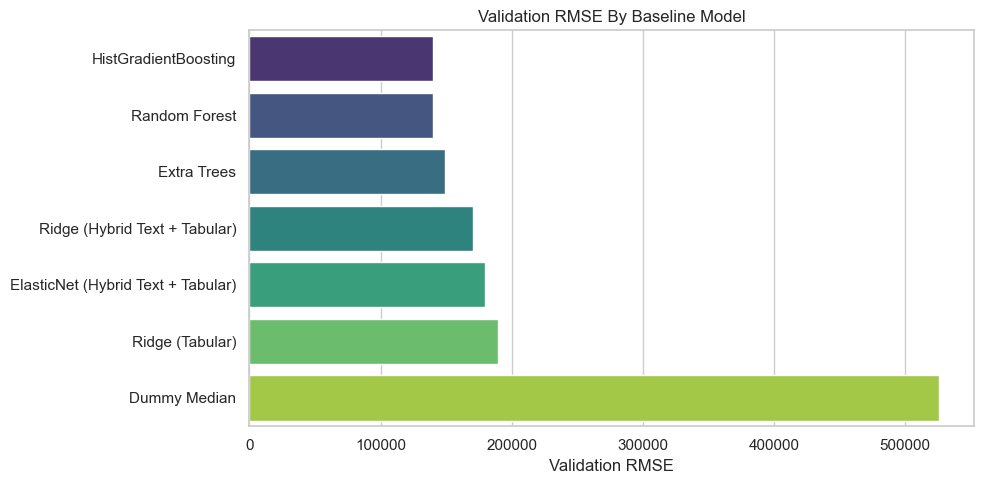

In [11]:
benchmark_results.to_csv(REPORTS_DIR / "benchmark_results.csv", index=False)
benchmark_fold_results.to_csv(REPORTS_DIR / "benchmark_fold_results.csv", index=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_results, x="val_rmse", y="model", palette="viridis")
plt.title("Validation RMSE By Baseline Model")
plt.xlabel("Validation RMSE")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 5. Tune The Strongest Challengers

After the first benchmark pass, we tune:
- the best hybrid sparse linear model
- the strongest pure tabular tree ensembles

This keeps runtime reasonable while still showing a serious model-selection workflow.


In [12]:
ridge_hybrid_base = benchmark_registry["Ridge (Hybrid Text + Tabular)"]
extra_trees_base = benchmark_registry["Extra Trees"]
hist_gbm_base = benchmark_registry["HistGradientBoosting"]

ridge_grid = {
    "regressor__model__alpha": [0.25, 0.5, 1.0, 2.0, 4.0, 8.0],
}

extra_trees_grid = {
    "regressor__model__n_estimators": [300, 500],
    "regressor__model__max_depth": [None, 20, 30],
    "regressor__model__min_samples_leaf": [1, 2, 4],
}

hist_gbm_grid = {
    "regressor__model__learning_rate": [0.03, 0.05, 0.1],
    "regressor__model__max_leaf_nodes": [15, 31, 63],
    "regressor__model__max_iter": [250, 400],
}

ridge_tuning, ridge_best_model, ridge_val_pred = tune_model(
    "Ridge Hybrid (Tuned)",
    ridge_hybrid_base,
    ridge_grid,
    X_train,
    y_train,
    X_val,
    y_val,
    cv,
)

extra_trees_tuning, extra_trees_best_model, extra_trees_val_pred = tune_model(
    "Extra Trees (Tuned)",
    extra_trees_base,
    extra_trees_grid,
    X_train,
    y_train,
    X_val,
    y_val,
    cv,
)

hist_gbm_tuning, hist_gbm_best_model, hist_gbm_val_pred = tune_model(
    "HistGradientBoosting (Tuned)",
    hist_gbm_base,
    hist_gbm_grid,
    X_train,
    y_train,
    X_val,
    y_val,
    cv,
)

tuning_results = pd.concat(
    [
        ridge_tuning.assign(search_family="ridge_hybrid"),
        extra_trees_tuning.assign(search_family="extra_trees"),
        hist_gbm_tuning.assign(search_family="hist_gradient_boosting"),
    ],
    ignore_index=True,
).sort_values("val_rmse")

display(tuning_results.head(10))


,model,regressor__model__alpha,cv_r2_mean,cv_mae_mean,cv_rmse_mean,val_r2,val_mae,val_rmse,search_family,regressor__model__max_depth,regressor__model__min_samples_leaf,regressor__model__n_estimators,regressor__model__learning_rate,regressor__model__max_iter,regressor__model__max_leaf_nodes
24,HistGradientBoosting (Tuned),NaN,0.881389,77657.019564,175289.632902,0.927421,72200.769547,138135.631177,hist_gradient_boosting,NaN,NaN,NaN,0.10,250.0,63.0
25,HistGradientBoosting (Tuned),NaN,0.884882,76536.868280,173445.073358,0.926322,72906.961630,139177.663439,hist_gradient_boosting,NaN,NaN,NaN,0.05,250.0,63.0
26,HistGradientBoosting (Tuned),NaN,0.886463,76044.614500,169995.989017,0.926161,72899.629840,139329.782237,hist_gradient_boosting,NaN,NaN,NaN,0.05,400.0,31.0
27,HistGradientBoosting (Tuned),NaN,0.882105,77103.212076,174204.966117,0.926062,73250.571023,139422.473085,hist_gradient_boosting,NaN,NaN,NaN,0.03,400.0,31.0
28,HistGradientBoosting (Tuned),NaN,0.880149,78607.912118,176140.266917,0.926042,73301.203460,139441.819164,hist_gradient_boosting,NaN,NaN,NaN,0.10,400.0,63.0
29,HistGradientBoosting (Tuned),NaN,0.886815,76363.859770,171736.881229,0.925957,73466.417396,139521.336824,hist_gradient_boosting,NaN,NaN,NaN,0.03,400.0,63.0
30,HistGradientBoosting (Tuned),NaN,0.886370,76513.142271,171684.444083,0.925626,73147.944726,139833.540560,hist_gradient_boosting,NaN,NaN,NaN,0.05,400.0,63.0
31,HistGradientBoosting (Tuned),NaN,0.884231,76819.848218,171627.757492,0.925140,73615.523473,140289.652450,hist_gradient_boosting,NaN,NaN,NaN,0.10,250.0,31.0
32,HistGradientBoosting (Tuned),NaN,0.882345,77145.862689,174078.634097,0.924881,73496.259019,140531.782906,hist_gradient_boosting,NaN,NaN,NaN,0.05,250.0,31.0
33,HistGradientBoosting (Tuned),NaN,0.879420,76921.133233,175284.108662,0.924548,72868.382942,140842.775108,hist_gradient_boosting,NaN,NaN,NaN,0.10,400.0,15.0


In [13]:
tuning_results.to_csv(REPORTS_DIR / "tuning_results.csv", index=False)

tuned_candidates = {
    "Ridge Hybrid (Tuned)": ridge_best_model,
    "Extra Trees (Tuned)": extra_trees_best_model,
    "HistGradientBoosting (Tuned)": hist_gbm_best_model,
}

tuned_validation_rows = []
tuned_validation_predictions = {
    "Ridge Hybrid (Tuned)": ridge_val_pred,
    "Extra Trees (Tuned)": extra_trees_val_pred,
    "HistGradientBoosting (Tuned)": hist_gbm_val_pred,
}

for name, predictions in tuned_validation_predictions.items():
    metrics = compute_regression_metrics(y_val, predictions)
    tuned_validation_rows.append({"model": name, **metrics})

tuned_validation_results = pd.DataFrame(tuned_validation_rows).sort_values("RMSE").reset_index(drop=True)
champion_name = tuned_validation_results.iloc[0]["model"]
champion_model_train_only = tuned_candidates[champion_name]
champion_val_pred = tuned_validation_predictions[champion_name]
champion_residual_std = float(np.std(y_val - champion_val_pred, ddof=1))

display(tuned_validation_results)
print(f"Champion selected on validation RMSE: {champion_name}")


,model,R2,MAE,RMSE
0,HistGradientBoosting (Tuned),0.927421,72200.769547,138135.631177
1,Extra Trees (Tuned),0.919407,76839.167485,145562.233892
2,Ridge Hybrid (Tuned),0.890374,76264.991313,169768.536637


Champion selected on validation RMSE: HistGradientBoosting (Tuned)


## 6. Final Held-Out Test Evaluation

Once the champion is chosen on validation data, we refit it on the combined development set (`train + validation`)
and evaluate **once** on the untouched test set.


In [14]:
X_dev = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

champion_model = clone(champion_model_train_only)
champion_model.fit(X_dev, y_dev)
test_pred = champion_model.predict(X_test)

final_metrics = compute_regression_metrics(y_test, test_pred)
final_metrics_df = pd.DataFrame([final_metrics], index=[champion_name])

test_results = X_test.reset_index(drop=True).copy()
test_results["actual_price"] = y_test.reset_index(drop=True)
test_results["predicted_price"] = test_pred
test_results["residual"] = test_results["actual_price"] - test_results["predicted_price"]
test_results["absolute_error"] = test_results["residual"].abs()

interval_width = 1.96 * champion_residual_std
test_results["prediction_interval_low"] = np.clip(
    test_results["predicted_price"] - interval_width,
    a_min=0,
    a_max=None,
)
test_results["prediction_interval_high"] = test_results["predicted_price"] + interval_width

display(final_metrics_df)
display(test_results.head())


,R2,MAE,RMSE
HistGradientBoosting (Tuned),0.897375,73452.786616,164725.405544


,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,actual_price,predicted_price,residual,absolute_error,prediction_interval_low,prediction_interval_high
0,Mahindra Bolero Power Plus SLX,2018,60000,Diesel,Individual,Manual,First Owner,16.5 kmpl,1493 CC,70 bhp,195Nm@ 1400-2200rpm,7.0,797000.0,7.439010e+05,53098.991343,53098.991343,4.746295e+05,1.013173e+06
1,Maruti Swift VDI,2013,67000,Diesel,Dealer,Manual,Second Owner,28.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,450000.0,4.040532e+05,45946.766352,45946.766352,1.347817e+05,6.733248e+05
2,Mahindra XUV500 AT W9 2WD,2018,20000,Diesel,Individual,Automatic,First Owner,16.0 kmpl,2179 CC,138 bhp,330Nm@ 1600-2800rpm,7.0,1500000.0,1.542735e+06,-42735.296065,42735.296065,1.273464e+06,1.812007e+06
3,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,110000,Diesel,Individual,Automatic,First Owner,17.11 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0,1200000.0,1.309736e+06,-109736.012490,109736.012490,1.040464e+06,1.579008e+06
4,Tata Tiago 1.05 Revotorq XT,2017,80000,Diesel,Individual,Manual,First Owner,27.28 kmpl,1047 CC,69 bhp,140Nm@ 1800-3000rpm,5.0,450000.0,3.931183e+05,56881.650522,56881.650522,1.238468e+05,6.623899e+05


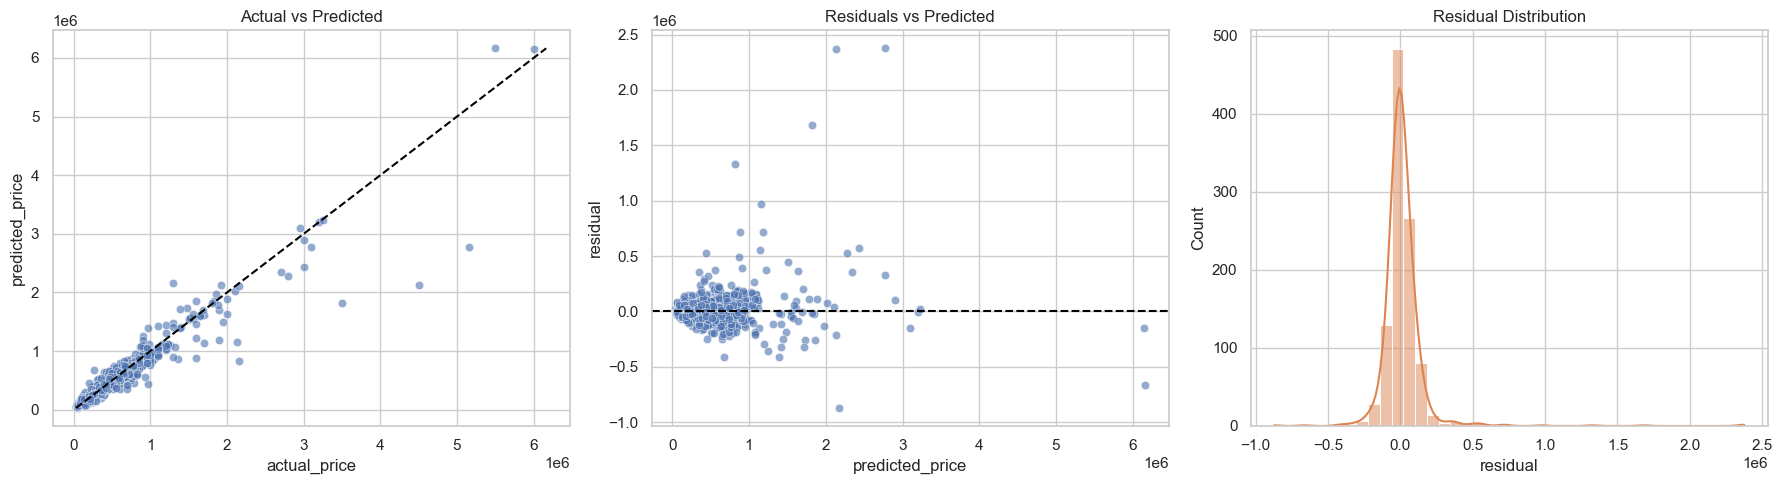

,listings,mean_absolute_error,mean_absolute_pct_error
fuel,,,
Diesel,575,92774.611427,0.161814
Petrol,447,50197.217852,0.165925
LPG,6,41872.178868,0.280199
CNG,11,25695.842761,0.109786


,listings,mean_absolute_error,mean_absolute_pct_error
transmission,,,
Automatic,87,229392.462072,0.153668
Manual,952,59201.996947,0.164634


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=test_results,
    x="actual_price",
    y="predicted_price",
    alpha=0.6,
    ax=axes[0],
)
min_price = min(test_results["actual_price"].min(), test_results["predicted_price"].min())
max_price = max(test_results["actual_price"].max(), test_results["predicted_price"].max())
axes[0].plot([min_price, max_price], [min_price, max_price], color="black", linestyle="--")
axes[0].set_title("Actual vs Predicted")

sns.scatterplot(
    data=test_results,
    x="predicted_price",
    y="residual",
    alpha=0.6,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals vs Predicted")

sns.histplot(test_results["residual"], bins=40, kde=True, ax=axes[2], color="#dd8452")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

segment_error_by_fuel = (
    test_results.assign(abs_pct_error=test_results["absolute_error"] / test_results["actual_price"])
    .groupby("fuel")
    .agg(
        listings=("fuel", "size"),
        mean_absolute_error=("absolute_error", "mean"),
        mean_absolute_pct_error=("abs_pct_error", "mean"),
    )
    .sort_values("mean_absolute_error", ascending=False)
)

segment_error_by_transmission = (
    test_results.assign(abs_pct_error=test_results["absolute_error"] / test_results["actual_price"])
    .groupby("transmission")
    .agg(
        listings=("transmission", "size"),
        mean_absolute_error=("absolute_error", "mean"),
        mean_absolute_pct_error=("abs_pct_error", "mean"),
    )
    .sort_values("mean_absolute_error", ascending=False)
)

display(segment_error_by_fuel)
display(segment_error_by_transmission)


,feature,importance
0,max_power,252592.635705
1,year,205944.156536
2,torque,99679.053299
3,name,52131.124704
4,transmission,31817.287715
5,km_driven,24021.577257
6,engine,18542.391496
7,mileage,9728.051926
8,owner,3310.732807
9,seller_type,2498.720635


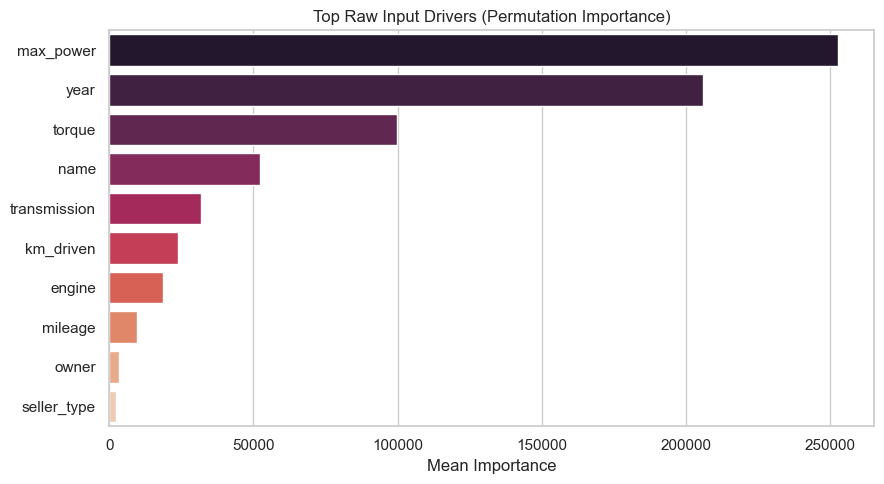

In [16]:
importance_sample = X_test.sample(n=min(len(X_test), 400), random_state=RANDOM_STATE)
importance_target = y_test.loc[importance_sample.index]

permutation = permutation_importance(
    champion_model,
    importance_sample,
    importance_target,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring=rmse_scorer,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": importance_sample.columns,
            "importance": permutation.importances_mean,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="rocket")
plt.title("Top Raw Input Drivers (Permutation Importance)")
plt.xlabel("Mean Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 7. Save The Deployment Artifact

The final artifact is a **single fitted object** that accepts raw listing columns and returns a price prediction.
That makes Streamlit integration much cleaner because the app does not need to reimplement training-time preprocessing.


In [17]:
model_path = MODELS_DIR / "used_car_price_champion.joblib"
metrics_path = REPORTS_DIR / "final_test_metrics.csv"
contract_path = ARTIFACTS_DIR / "inference_contract.json"
sample_payload_path = ARTIFACTS_DIR / "sample_inference_payload.json"

joblib.dump(champion_model, model_path)
final_metrics_df.to_csv(metrics_path)

sample_payload = X_test.head(3).copy()
with open(sample_payload_path, "w", encoding="utf-8") as file:
    json.dump(sample_payload.to_dict(orient="records"), file, indent=2)

inference_contract = {
    "raw_feature_columns": RAW_FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "model_artifact": model_path.name,
    "prediction_field": "predicted_price",
    "notes": {
        "artifact_accepts_raw_listing_inputs": True,
        "text_feature_is_built_from_name_column": True,
        "target_was_modeled_in_log_space": True,
    },
}

with open(contract_path, "w", encoding="utf-8") as file:
    json.dump(inference_contract, file, indent=2)

loaded_model = joblib.load(model_path)
smoke_predictions = loaded_model.predict(sample_payload)

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")
print(f"Saved inference contract to: {contract_path}")
print(f"Saved sample payload to: {sample_payload_path}")
print("Smoke-test predictions:", smoke_predictions.round(2))


Saved model to: /Users/dannyyy/Downloads/BCU projects/3Y: Machine Learning/models/used_car_price_champion.joblib
Saved metrics to: /Users/dannyyy/Downloads/BCU projects/3Y: Machine Learning/reports/final_test_metrics.csv
Saved inference contract to: /Users/dannyyy/Downloads/BCU projects/3Y: Machine Learning/artifacts/inference_contract.json
Saved sample payload to: /Users/dannyyy/Downloads/BCU projects/3Y: Machine Learning/artifacts/sample_inference_payload.json
Smoke-test predictions: [ 743901.01  404053.23 1542735.3 ]


## 8. Streamlit Handoff Notes

For the future app, the simplest flow is:

1. Build a small input form that collects the raw listing fields.
2. Convert the form submission into a one-row `pandas.DataFrame`.
3. Load `models/used_car_price_champion.joblib`.
4. Call `.predict(raw_input_frame)` and display the output.

Because the model artifact already contains:
- raw schema expectations
- feature engineering
- preprocessing
- the fitted estimator

...the Streamlit app can stay thin and focused on the user experience.
